# Strategy: Costs, Markups, and Profit

## Imports

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv("bluetooth_speakers_brand_year.csv")
df.head()

,category,year,brand,n_users,unique_users,purchase_count,product_count,avg_price,avg_rating,waterproof_share,...,user_share,brand_share,log_brand_share,raw_brand_share,provided_dprime,provided_revenue,provided_elasticity,provided_markup,provided_marginal_cost,provided_profit
0,bluetooth_speakers,2015,Anker,79,79,79,1.0,63.329873,4.529114,0.000000,...,0.003944,0.010931,-4.516131,0.003944,-4.986487,5228.398139,-3.823502,16.556379,46.773494,1366.864286
1,bluetooth_speakers,2015,Bose,4212,4212,4212,1.0,141.189855,4.533974,0.000000,...,0.210295,0.582814,-0.539886,0.210295,-112.445619,292006.078888,-6.758300,18.392716,122.797139,38039.452873
2,bluetooth_speakers,2015,JBL,2832,2832,2832,1.0,78.035332,4.383510,0.000353,...,0.141395,0.391864,-0.936841,0.141395,-224.283797,382256.778623,-4.061195,21.840673,56.194659,106986.733199
3,bluetooth_speakers,2015,OontZ,104,104,104,1.0,45.456538,3.659615,0.000000,...,0.005192,0.014390,-4.241188,0.005192,-7.193995,5424.204808,-2.740972,16.587066,28.869472,1979.289393
4,bluetooth_speakers,2016,Anker,2982,2982,2982,1.0,37.254859,4.679376,0.000000,...,0.112831,0.221825,-1.505864,0.112831,-121.670448,81504.170248,-2.003358,17.980915,19.273944,39337.676322


**Q1: What are the average unit costs and markups for each brand over the years?**

In [3]:
results = (
    df.groupby("brand")[["provided_marginal_cost", "provided_markup"]]
    .mean()
    .reset_index()
    .sort_values("provided_marginal_cost", ascending=False)
)

results

,brand,provided_marginal_cost,provided_markup
1,Bose,137.646543,18.233182
3,JBL,97.181518,19.791612
2,DOSS,34.852054,16.724884
4,OontZ,34.073982,17.133317
0,Anker,33.486373,19.295045


Bose has the highest average unit cost, followed by JBL, while Anker, DOSS, and OontZ have much lower costs. Markups are relatively similar across brands, generally around 16–20.

**Q2: Are any inferred unit costs negative? If so, what might that mean?**

No, there are no negative inferred unit costs in this dataset. If there were, it would suggest issues with the estimation model or unusual data.

**Q3: Which brands have the highest average unit costs? How do average unit cost and average ratings compare? Make scatter plots of price vs. unit cost and average rating vs. unit cost.Do more expensive products have higher consumer satisfaction?**

In [4]:
brand_summary = (
    df.groupby("brand")[["provided_marginal_cost", "avg_rating"]]
    .mean()
    .reset_index()
    .sort_values("provided_marginal_cost", ascending=False)
)

brand_summary

,brand,provided_marginal_cost,avg_rating
1,Bose,137.646543,4.647972
3,JBL,97.181518,4.628324
2,DOSS,34.852054,4.531629
4,OontZ,34.073982,4.386703
0,Anker,33.486373,4.648906


Bose and JBL have the highest average unit costs. However, higher unit cost does not clearly lead to higher ratings, since all brands have similar ratings.

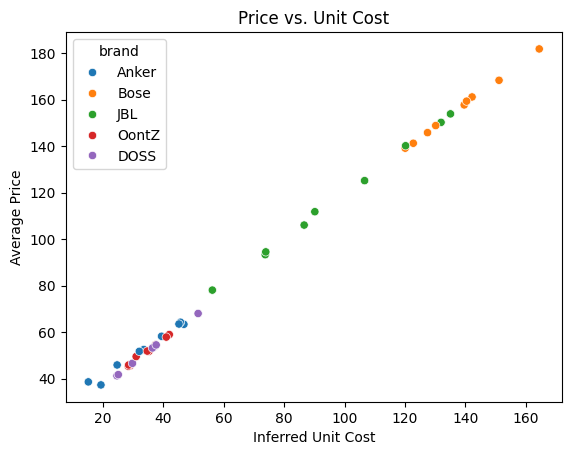

In [5]:
sns.scatterplot(data=df, x="provided_marginal_cost", y="avg_price", hue="brand")
plt.xlabel("Inferred Unit Cost")
plt.ylabel("Average Price")
plt.title("Price vs. Unit Cost")
plt.show()

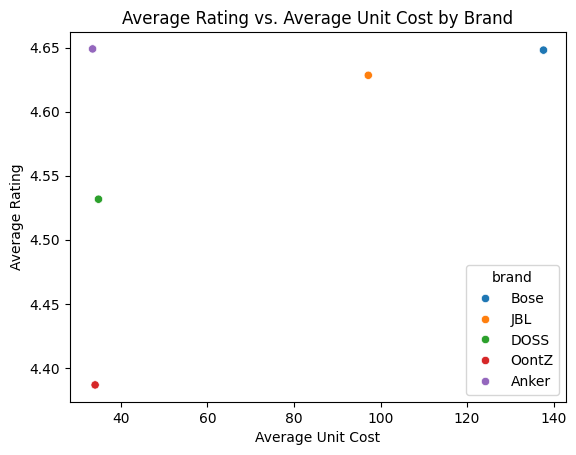

In [6]:
sns.scatterplot(data=brand_summary, x="provided_marginal_cost", y="avg_rating", hue="brand")
plt.xlabel("Average Unit Cost")
plt.ylabel("Average Rating")
plt.title("Average Rating vs. Average Unit Cost by Brand")
plt.show()

There is no strong relationship between higher price or cost and higher consumer ratings.

**Q4: Make kernel density plots of unit costs, markups, and average profit, in general and hued by brand.**

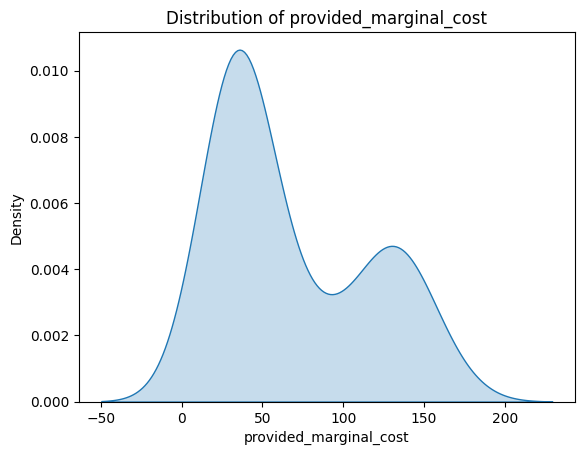

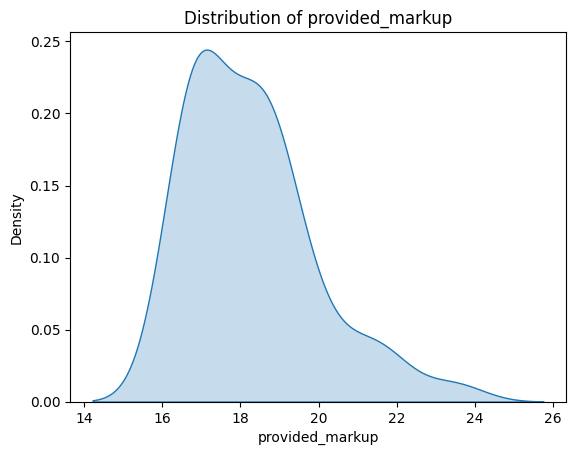

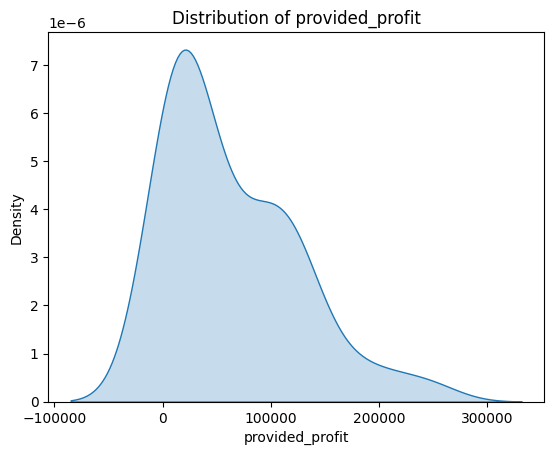

In [7]:
cols = ["provided_marginal_cost", "provided_markup", "provided_profit"]

for col in cols:
    sns.kdeplot(data=df, x=col, fill=True)
    plt.title(f"Distribution of {col}")
    plt.show()

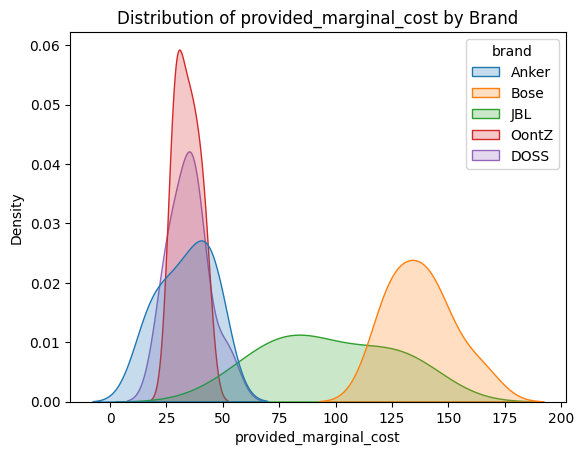

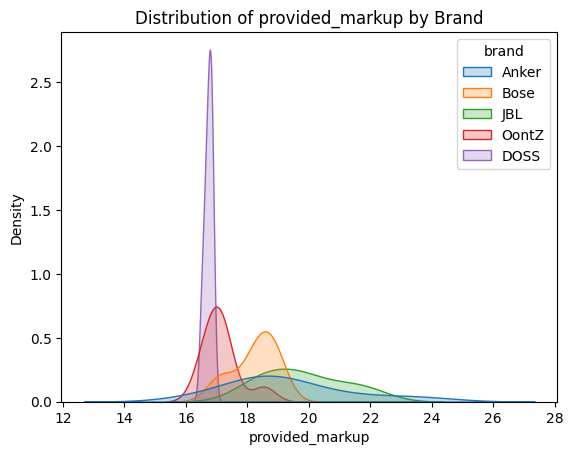

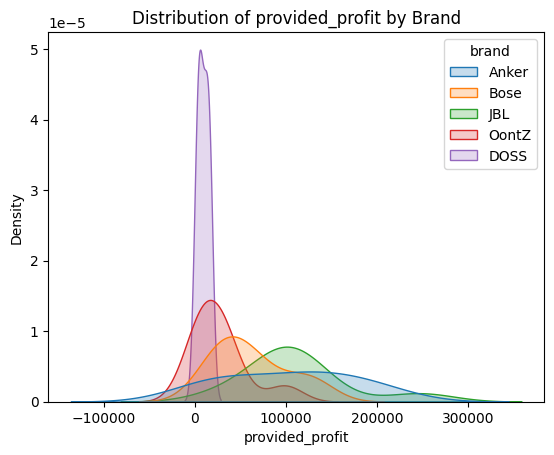

In [8]:
for col in cols:
    sns.kdeplot(data=df, x=col, hue="brand", fill=True, common_norm=False)
    plt.title(f"Distribution of {col} by Brand")
    plt.show()

**Q5: Which brands have the highest share-weighted average profit?**

In [9]:
df["weighted_profit"] = df["brand_share"] * df["provided_profit"]

weighted_profit = (
    df.groupby("brand")
    .apply(lambda x: x["weighted_profit"].sum() / x["brand_share"].sum())
    .reset_index(name="share_weighted_avg_profit")
    .sort_values("share_weighted_avg_profit", ascending=False)
)

weighted_profit

/tmp/ipykernel_33366/1580771417.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x["weighted_profit"].sum() / x["brand_share"].sum())


,brand,share_weighted_avg_profit
0,Anker,120351.687383
3,JBL,107883.242325
1,Bose,54035.020999
4,OontZ,42265.674124
2,DOSS,11334.779406


Anker has the highest share-weighted average profit, followed by JBL, with DOSS having the lowest.

To conclude, higher costs and prices do not strongly predict consumer satisfaction, suggesting other factors influence ratings and profitability.